In [1]:
%matplotlib notebook

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


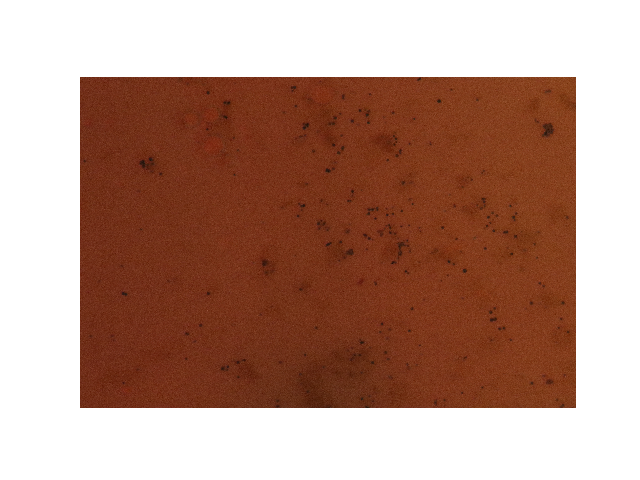

In [11]:
img_dir = "/home/eholum/Documents/cell_counting/images/"

img = cv2.cvtColor(cv2.imread(img_dir + "IMG_4641.JPG"), cv2.COLOR_BGR2RGB)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(img)
ax.axis('off')
fig.show()

<IPython.core.display.Javascript object>


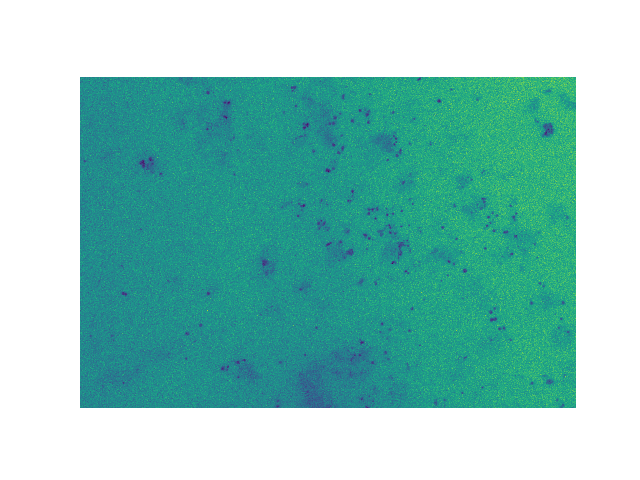

<IPython.core.display.Javascript object>


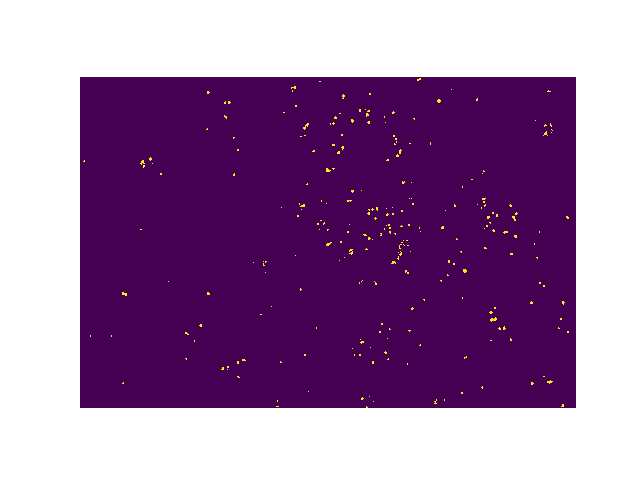

<IPython.core.display.Javascript object>


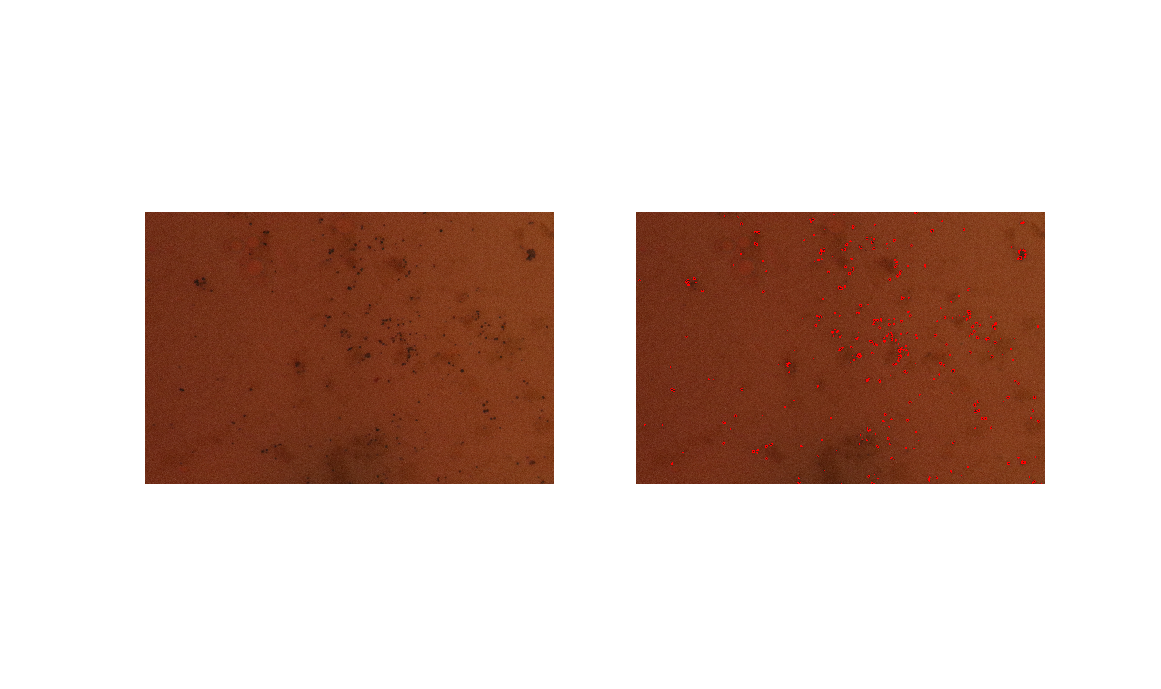

In [27]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
binary_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 235, 15)


erosion_kernel=np.ones((3,3), dtype=np.uint8)
dilation_kernel=np.ones((3,3), dtype=np.uint8)

binary_img = cv2.erode(binary_img, erosion_kernel, iterations=1)
binary_img = cv2.dilate(binary_img, dilation_kernel, iterations=2)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(gray_img)
ax.axis('off')
fig.show()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(binary_img)
ax.axis('off')
fig.show()

contours, hier = cv2.findContours(binary_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
# cv2.drawContours(img3, contours, -1, (0,255,0), 3)

# Min area for rectangle
min_size = 1
rects = []
for contour in contours:
    (x,y,w,h) = cv2.boundingRect(contour)
    
    if w*h > min_size:
        rects.append([w*h, x, y, w, h])
rects = np.array(rects)

cimg = np.copy(img)
cv2.drawContours(cimg, contours, -1, (255,0,0), thickness=10)

fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.imshow(img)
ax.axis('off')

ax = fig.add_subplot(1,2,2)
ax.imshow(cimg)
ax.axis('off')
fig.show()


<IPython.core.display.Javascript object>


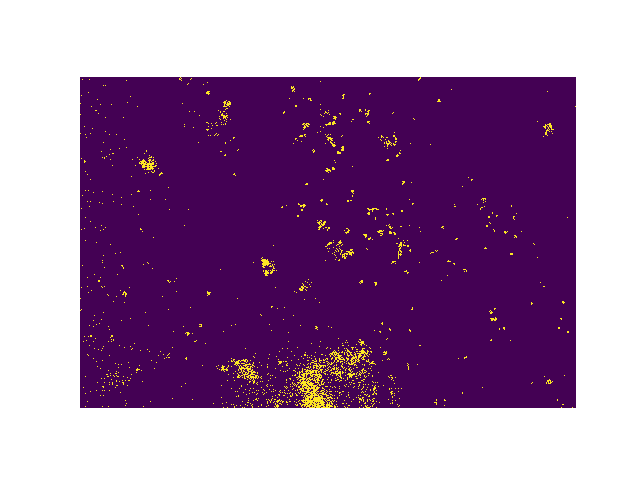

<IPython.core.display.Javascript object>


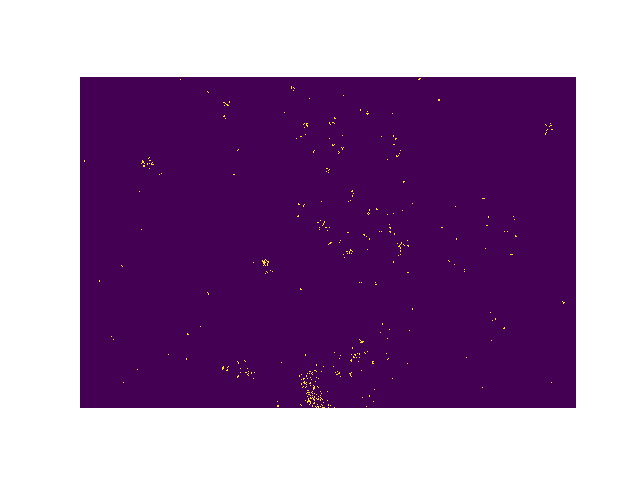

In [13]:
cell_lower = np.array([20,10,5])
cell_upper = np.array([100,40,20])
pixels = cv2.inRange(img, cell_lower, cell_upper)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(pixels)
ax.axis('off')
fig.show()


erosion_kernel=np.ones((3,3), dtype=np.uint8)
dilation_kernel=np.ones((3,3), dtype=np.uint8)

pixels = cv2.erode(pixels, erosion_kernel, iterations=1)
# pixels = cv2.dilate(pixels, dilation_kernel, iterations=1)


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(pixels)
ax.axis('off')
fig.show()